# Movie Rating Prediction
A collaborative filtering model trained on the MovieLens 100K dataset to predict how a user might rate a movie they haven't seen yet. User-movie ratings are preprocessed into a utility matrix, and a Singular Value Decomposition (SVD) model learns latent patterns in user preferences and movie characteristics to generate personalized rating predictions evaluated using MAE and RMSE.

In [1]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
# Loading ratings and movies datasets
ratings = pd.read_csv('ratings.csv')
movies = pd.read_csv('movies.csv')

print(ratings.shape)
print(movies.shape)
ratings.head()

(100836, 4)
(9742, 3)


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [3]:
# Checking for null values and data types
ratings.info()
ratings.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB


userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

In [4]:
# Merging ratings with movie titles for readability
df = ratings.merge(movies, on='movieId')
df.drop('timestamp', axis=1, inplace=True)
df.head()

,userId,movieId,rating,title,genres
0,1,1,4.0,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


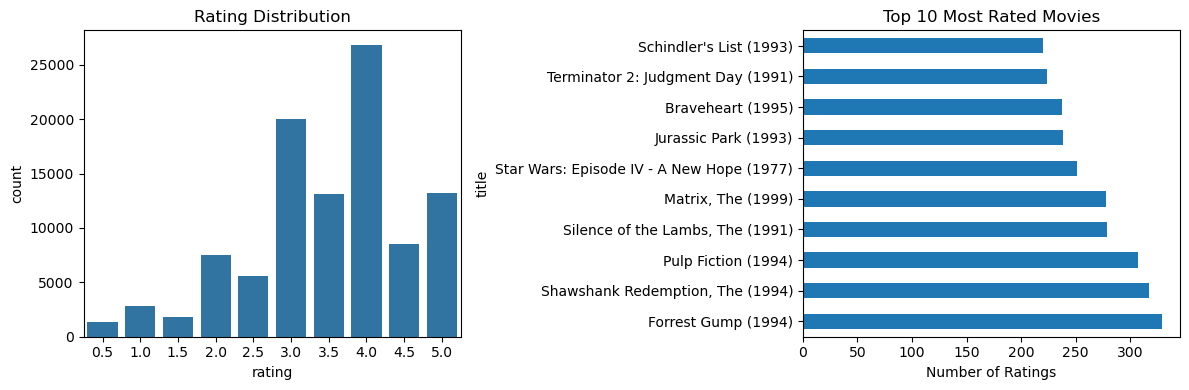

In [5]:
# Visualizing rating distribution and most rated movies
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.countplot(x='rating', data=df)
plt.title('Rating Distribution')

plt.subplot(1, 2, 2)
df.groupby('title')['rating'].count().sort_values(ascending=False).head(10).plot(kind='barh')
plt.title('Top 10 Most Rated Movies')
plt.xlabel('Number of Ratings')
plt.tight_layout()
plt.show()

In [6]:
pip install scikit-surprise

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'error'
Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  Getting requirements to build wheel did not run successfully.
  exit code: 1
  
  [44 lines of output]
  
  Error compiling Cython file:
  ------------------------------------------------------------
  ...
          self.avg_cltr_i = avg_cltr_i
          self.avg_cocltr = avg_cocltr
  
          return self
  
      def compute_averages(self, np.ndarray[np.int_t] cltr_u,
                                               ^
  ------------------------------------------------------------
  surprise\prediction_algorithms\co_clustering.pyx:157:45: Invalid type.
  Compiling surprise/similarities.pyx because it changed.
  Compiling surprise/prediction_algorithms/matrix_factorization.pyx because it changed.
  Compiling surprise/prediction_algorithms/optimize_baselines.pyx because it changed.
  Compiling surprise/prediction_algorithms/slope_one.pyx because it changed.
  Compiling surprise/prediction_algorithms/co_clustering.pyx because it changed.
  [1/5] 

In [12]:
# Importing SVD from scipy for matrix factorization
from scipy.sparse.linalg import svds
from scipy.sparse import csr_matrix

In [13]:
# Creating user-movie rating matrix
user_movie_matrix = df.pivot_table(
    index='userId', 
    columns='title', 
    values='rating'
).fillna(0)

print(user_movie_matrix.shape)

(610, 9719)


In [16]:
# Normalizing ratings and applying SVD to find latent patterns
matrix = user_movie_matrix.values
user_ratings_mean = np.mean(matrix, axis=1)
matrix_demeaned = matrix - user_ratings_mean.reshape(-1, 1)

U, sigma, Vt = svds(matrix_demeaned, k=50)
sigma = np.diag(sigma)

In [17]:
# Reconstructing full predicted ratings matrix from SVD components
predicted_ratings = np.dot(np.dot(U, sigma), Vt) + user_ratings_mean.reshape(-1, 1)
predicted_df = pd.DataFrame(
    predicted_ratings, 
    columns=user_movie_matrix.columns,
    index=user_movie_matrix.index
)

print(predicted_df.shape)

(610, 9719)


In [18]:
# Evaluating model performance using MAE and RMSE on known ratings
from sklearn.metrics import mean_absolute_error, mean_squared_error

actual = []
predicted = []

for _, row in df.iterrows():
    user = row['userId']
    movie = row['title']
    actual.append(row['rating'])
    predicted.append(predicted_df.loc[user, movie])

mae = mean_absolute_error(actual, predicted)
rmse = np.sqrt(mean_squared_error(actual, predicted))
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

MAE: 1.5325
RMSE: 1.9965


In [19]:
# Recommending top unrated movies for a given user based on predicted ratings
def recommend_movies(user_id, num_recommendations=10):
    user_ratings = user_movie_matrix.loc[user_id]
    already_rated = user_ratings[user_ratings > 0].index.tolist()
    
    predictions = predicted_df.loc[user_id]
    recommendations = predictions.drop(already_rated).sort_values(ascending=False)
    
    return recommendations.head(num_recommendations)

print(recommend_movies(1))

title
Die Hard (1988)                   4.023800
Godfather: Part II, The (1974)    3.326251
Jaws (1975)                       3.303518
Godfather, The (1972)             2.894619
Breakfast Club, The (1985)        2.870946
Stand by Me (1986)                2.786809
Christmas Story, A (1983)         2.586165
Lady and the Tramp (1955)         2.443928
Snatch (2000)                     2.392970
Little Mermaid, The (1989)        2.383524
Name: 1, dtype: float64


In [ ]:
print("3" + 2)